# Citation Network Analysis with Toponymy

This notebook demonstrates how to build and analyze a one-hop citation network using the Semantic Scholar API and Toponymy.

**What this example does:**
1. Fetches an author's publications from Semantic Scholar
2. Retrieves all papers that cite those publications (one-hop citation network)
3. Embeds the paper titles and abstracts
4. Uses Toponymy to discover hierarchical topics in the citation network
5. Visualizes the results with an interactive DataMap

**Note**: This example uses John Healy's citation data (one of Toponymy's authors) as a convenient, moderately-sized dataset for demonstration. You can substitute any Semantic Scholar author ID.

**⚠️ EXAMPLE CODE DISCLAIMER ⚠️**

The `semantic_scholar_utils.py` module used in this example is provided as-is for educational purposes. It is not maintained as part of the core Toponymy package and may break if the Semantic Scholar API changes. Feel free to copy and modify it for your own projects.

## Prerequisites

First, install Toponymy with the `dev` extras, which includes all dependencies needed for this example:

```bash
pip install toponymy[dev]
```

For this notebook you'll also need a Cohere API key for embeddings and topic naming. Set it as an environment variable:

```bash
export COHERE_API_KEY="your-key-here"
```

Alternatively, you can use:
- `OpenAINamer()` with `OPENAI_API_KEY`
- `AnthropicNamer()` with `ANTHROPIC_API_KEY`
- Local embeddings with `SentenceTransformer('all-MiniLM-L6-v2')` (no API key needed)

## Getting the Example Code

This example uses a custom `semantic_scholar_utils.py` module to handle Semantic Scholar API queries with best practices (caching, rate limiting, pagination). This is **not part of the Toponymy package**, it's standalone example code provided in the documentation.

**Download from GitHub**
```bash
wget https://raw.githubusercontent.com/TutteInstitute/toponymy/main/doc/semantic_scholar_utils.py
```

or copy it from the [Toponymy repository](https://github.com/TutteInstitute/toponymy/blob/main/doc/semantic_scholar_utils.py) and save it in your working directory.

In [1]:
from semantic_scholar_utils import build_citation_network

In [2]:
# Standard library
import json
from pathlib import Path

# Data processing and numerical computing
import numpy as np
import pandas as pd

# Embedding and dimensionality reduction
from toponymy.embedding_wrappers import CohereEmbedder 
import umap

# Toponymy for topic modeling
from toponymy import Toponymy, ToponymyClusterer
from toponymy.llm_wrappers import CohereNamer

# Visualization
import datamapplot

## Configuration

Set the Semantic Scholar author ID and file paths. This example uses John Healy's author ID which you should replace with any author ID from Semantic Scholar. The cache database and API key file will be created in the same directory as this notebook.

In [3]:
AUTHOR_ID = "2062756303"
SEMANTIC_SCHOLAR_API_KEY_FILE = Path("api_key_semantic_scholar.txt")
CACHE_DB = Path("semantic_scholar_cache.db")

## Step 1: Build Citation Network

Fetch the author's papers and their citing papers from Semantic Scholar.

This step demonstrates:
- Efficient API usage (bulk endpoints, inline field requests)
- SQLite caching (subsequent runs are nearly instant)
- Rate limiting and exponential backoff

**API Key (optional but recommended):** If you have a Semantic Scholar API key, 
save it to `api_key_semantic_scholar.txt` in this directory. This increases rate 
limits from 1 request/10 sec to 1 request/3 sec. Get a free key at 
https://www.semanticscholar.org/product/api

In [4]:
ss_api_key = SEMANTIC_SCHOLAR_API_KEY_FILE.read_text().strip() if SEMANTIC_SCHOLAR_API_KEY_FILE.exists() else None
if ss_api_key is None:
    print("⚠ No API key - queries will be slower (1 request/10 sec instead of 1 request/3 sec)")

Now let's use that custom code we imported from `semantic_scholar_utils` in order to query and cache our author's citations.

The `author_id` is a Semantic Scholar author id which can be found on the [Semantic Scholar](https://www.semanticscholar.org/) website.

The `cache_db` path points to a SQLite database where API responses will be cached. On first run, this will query Semantic Scholar. Subsequent runs will use the cache and complete almost instantly.

In [5]:
network_data = build_citation_network(
    author_id=AUTHOR_ID,
    api_key=ss_api_key,
    cache_db=CACHE_DB,
    verbose=True
)


Building citation network for author 2062756303
✓ Using API key (rate limit: 1 request/3 sec)

📊 Cache status (semantic_scholar_cache.db):
  • 1 authors cached
  • 23,835 papers cached
  • 14 citation queries cached

Step 1: Fetching author's publications with citations...
✓ Retrieved 14 papers

Step 2: Extracting citations...
  Found 0 citations from inline data
  12 papers need separate queries (30,071 total citations)

Step 3: Fetching citations with full metadata for 12 papers...
  [1/12] Fetching citations for paper with 308 citations (cached)
  [2/12] Fetching citations for paper with 137 citations (cached)
  [3/12] Fetching citations for paper with 56 citations (cached)
  [4/12] Fetching citations for paper with 4,779 citations (cached)
  [5/12] Fetching citations for paper with 13,142 citations (cached)
  [6/12] Fetching citations for paper with 8,181 citations (cached)
  [7/12] Fetching citations for paper with 16 citations (cached)
  [8/12] Fetching citations for paper with 

## Step 2: Prepare Data for Analysis

Convert to a DataFrame and combine titles and abstracts.

In [6]:
df = pd.DataFrame(network_data['citing_papers'])
documents = df['title'] + '. ' + df['abstract']

It's always good to look at your data.  Let's do a quick document statistics summary to avoid some common pitfalls. Empty documents and massive documents can be equally problematic for this kind of topic modeling procedure.

In [7]:
doc_lengths = documents.str.len()
doc_lengths.describe()

count    19984.000000
mean      1526.060649
std        517.616104
min        102.000000
25%       1213.000000
50%       1470.000000
75%       1769.000000
max       9329.000000
dtype: float64

Let's look at a quick sample of the documents.

In [8]:
df[['title', 'year']].head(10)

,title,year
0,Stable Learning for Trustworthy Modeling in In...,2026.0
1,Scikit-fingerprints: Python library for scikit...,2026.0
2,Separation of Multisource Partial Discharges B...,2026.0
3,On a joint simultaneous learning of relevant f...,2026.0
4,An Instrument to Evaluate Governance Proposals...,2026.0
5,A Lightweight Foundation Model for Collider Ph...,2026.0
6,FAIR: Feature-Augmented Implicit Regularizatio...,2026.0
7,An unsupervised clustering analysis of breast ...,2026.0
8,Deciphering spatial heterogeneity by multimoda...,2026.0
9,Early Immune Hypoactivation and Persistent Inn...,2026.0


## Step 3: Embed the Papers

Use Sentence Transformers to create dense vector representations of the papers.

**Note**: This example uses Cohere for embeddings, which requires a `COHERE_API_KEY` environment variable.

**Alternative - Local embeddings (no API key needed):**

If you don't have a Cohere API key, you can use a local SentenceTransformer model instead:

```python
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(
    documents.to_list(),
    show_progress_bar=True
)
```

This will run entirely locally without requiring any API keys, though it may be slower for large datasets.

In [9]:
embedding_model = CohereEmbedder(
    model="embed-multilingual-v3.0"  # Strong for search/retrieval tasks
)

embeddings = embedding_model.encode(
    texts=documents.to_list(),
    verbose=True 
)

embedding texts:   0%|          | 0/209 [00:00<?, ?it/s]

## Step 4: Create 2D Map with UMAP

Reduce embeddings to 2D for visualization while preserving local structure.

In [10]:
reducer = umap.UMAP(metric='cosine')
document_map = reducer.fit_transform(embeddings)

We've now created a 2 dimensional representation of our citation network. 

## Step 5: Run Toponymy for Topic Modeling

Now we'll use Toponymy to discover topics in the citation network using Cohere's models.

**Note**: This requires a Cohere API key (`COHERE_API_KEY`). The key should be set in your environment.

If you don't have a Cohere API key, you can use a different LLM wrapper (like `OpenAINamer()` or `AnthropicNamer()`) or skip this step and create visualizations with unlabeled clusters.

It can be handy to build and fit the clusterer ahead of time to ensure that you like the resolution for your corpus.

In [11]:
clusterer = ToponymyClusterer(min_samples=30)
clusterer.fit(document_map, embeddings, verbose=True);

Layer 0 found 164 clusters
Layer 1 found 56 clusters
Layer 2 found 18 clusters
Layer 3 found 7 clusters


In [12]:
toponymy_model = Toponymy(
    llm_wrapper=CohereNamer(),  # Uses command-r-08-2024 model
    text_embedding_model=embedding_model,
    clusterer=clusterer,
    object_description="academic papers",
    corpus_description="citation network papers",
    verbose=True
)

In [13]:
toponymy_model.fit(documents, embeddings, document_map)

Selecting central exemplars:   0%|          | 0/164 [00:00<?, ?cluster/s]

embedding texts:   0%|          | 0/521 [00:00<?, ?it/s]

Building topic names by layer:   0%|          | 0/4 [00:00<?, ?layer/s]

Generating informative keyphrases:   0%|          | 0/164 [00:00<?, ?cluster/s]

Generating prompts for layer 0:   0%|          | 0/164 [00:00<?, ?topic/s]

...

Generating informative keyphrases:   0%|          | 0/7 [00:00<?, ?cluster/s]

Selecting central subtopics:   0%|          | 0/7 [00:00<?, ?cluster/s]

Generating prompts for layer 3:   0%|          | 0/7 [00:00<?, ?topic/s]

Generating topic names for layer 3:   0%|          | 0/7 [00:00<?, ?topic/s]

embedding texts:   0%|          | 0/1 [00:00<?, ?it/s]

For this specific dataset we've built a topic model on **19,984 documents** and discovered 
**4 hierarchical topic layers**. This hierarchical structure allows 
exploration at different levels of granularity.

## Step 6: Explore and Analyze Topics

After being fit a Toponymy object has a `topic_tree_` with an html representation that you can expand and explore.

In [14]:
toponymy_model.topic_tree_

For the more visual users we can use the Tutte Institute's [DataMapPlot](https://github.com/TutteInstitute/datamapplot) library to build a DataMap showing the citation network colored by discovered topics. Feel free to choose the resolution level that suits your needs. Here we choose the third layer.

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


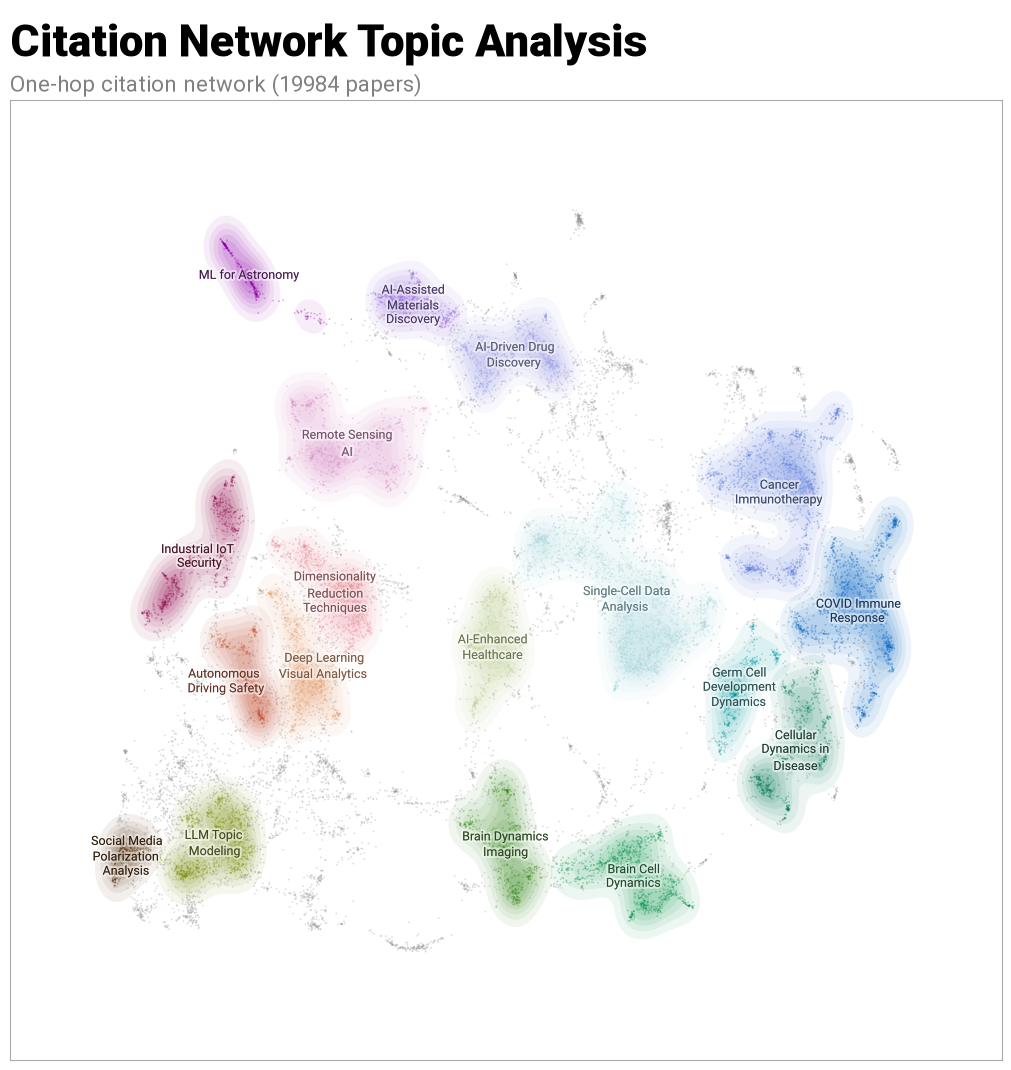

In [15]:
topic_names_per_point = toponymy_model.topic_name_vectors_[2]

plot = datamapplot.create_plot(
    document_map,
    topic_names_per_point,
    title="Citation Network Topic Analysis",
    sub_title=f"One-hop citation network ({len(df)} papers)",
    label_over_points=True,
)

Now that we have topic assignments, we can enrich our papers DataFrame and explore the citation network by topic.

In [16]:
df['topic'] = toponymy_model.topic_name_vectors_[0]
df.topic.value_counts()

topic
Unlabelled                                                                    10827
Machine Learning for Materials Discovery                                        252
Human Microbiome Genomics and AMR                                               192
Advanced Topic Modeling Techniques for Text Analysis                            176
Social Media Polarization Dynamics                                              171
                                                                              ...  
AI-Assisted Customer Engagement Strategies                                       12
Gastric Cancer Microenvironment Dynamics                                         11
Visualizing High-Dimensional Data with Dimensionality Reduction Techniques       10
Stem Cell Models of Mammalian Development                                        10
Deep Learning for Microscopy Image Analysis                                      10
Name: count, Length: 165, dtype: int64

Let's examine papers in the second-most common topic:

In [17]:
topic_of_interest = df.topic.value_counts().index[1]
print(f"Papers in '{topic_of_interest}':")
df[df['topic'] == topic_of_interest][['title', 'year', 'citationCount']].head()

Papers in 'Machine Learning for Materials Discovery':


,title,year,citationCount
44,Deciphering Majorana Zero Modes in Topological...,2026.0,0
140,Transformer-generated atomic embeddings to enh...,2025.0,32
213,Inferring topological transitions in pattern-f...,2022.0,10
247,Surface Acoustic Wave-Guided Reconfigurable Me...,2026.0,0
255,Guided Adaptive Diffusion: An Evolutionary Fra...,2026.0,0


For persistent storage of topic models with metadata, see 
[Saving and Loading Topic Models](saving_loading.ipynb).

## Summary

This notebook demonstrated a complete pipeline for citation network analysis:

1. **Data Collection**: Efficiently queried Semantic Scholar API with caching and rate limiting
2. **Embedding**: Converted papers to dense vectors using Sentence Transformers
3. **Dimensionality Reduction**: Created 2D map with UMAP
4. **Topic Discovery**: Used Toponymy to discover and name hierarchical topics
5. **Visualization**: Created DataMap for exploration

### Next Steps

You can extend this analysis by:
- Analyzing different authors or citation networks
- Merging author citation networks
- Comparing citation networks across time periods
- Using different embedding models or dimensionality reduction techniques

### API Efficiency

This notebook demonstrated several API best practices:
- **Inline field requests**: Fetched full paper metadata with citations (no separate batch calls)
- **SQLite caching**: Subsequent runs reuse cached data (nearly instant)
- **Time-slicing**: Bypassed the 10,000-item pagination limit using year filters
- **Exponential backoff**: Automatic retry with increasing delays on errors
- **Rate limiting**: Respects API limits (3 seconds between requests with API key)